# Toy example to check KL div loss

In [1]:
import numpy as np
import torch
from sklearn.cluster import KMeans
from torch.nn import KLDivLoss
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.manifold import TSNE
import wandb

from nnfabrik.utility.nn_helpers import set_random_seed
from scipy.special import gamma, digamma


seed = 42
set_random_seed(seed)
torch.cuda.is_available()
cuda_number = 5
torch.cuda.set_device(f"cuda:{cuda_number}")
device = f'cuda:{cuda_number}'

In [2]:
cluster_number=2
dec_starting_epoch=30
alpha=1.0
kmeans_init=20
base_multiplier=4e3
exponent=1.2
data_spread = 5

In [3]:
from sklearn.datasets import make_blobs

# Generate a 5D dataset with two clusters
n_samples = 500
n_features = 4
n_clusters = cluster_number
X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=n_clusters, random_state=42)
max_abs = 10  # Example threshold
X = X / np.max(np.abs(X), axis=0) 

# Print shape to verify
print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

Feature matrix shape: (500, 4)
Labels shape: (500,)


In [4]:
def generate_functions():
    functions = []

    # Cluster 1: Small variations (close to np.sum(X, axis=1))
    for i in range(15):
        shift = np.random.uniform(0, 0.001)  # Tiny shifts
        functions.append(lambda X, s=shift: np.sum(X, axis=1) + s)

    # Cluster 2: Large shifts (well-separated from cluster 1)
    for i in range(30):
        shift = np.random.uniform(5, 5.5)  # Large shifts
        functions.append(lambda X, s=shift: np.sum(X, axis=1) + s)

    return functions

# Apply functions
def apply_functions(X):
    functions = generate_functions()
    return np.column_stack([f(X) for f in functions])

f = apply_functions(X)
print(f[0,:])

[-1.30875997 -1.3081838  -1.30840252 -1.30853585 -1.30897849 -1.30897852
 -1.30907643 -1.30826834 -1.3085334  -1.30842644 -1.30911393 -1.3081646
 -1.30830207 -1.30892217 -1.30895269  3.78256774  3.84298661  3.9532437
  3.906838    3.83648006  3.99679194  3.76061242  3.83693781  3.87404641
  3.91890048  4.08345347  3.79070238  3.94798271  3.98707277  3.71409069
  3.99463791  3.77612755  3.72339129  4.16530826  4.17368151  4.09506416
  3.84317237  3.73970155  4.032982    3.91094174  3.75188461  3.93845394
  3.70805975  4.14552569  3.82025548]


Visualisation using kmeans

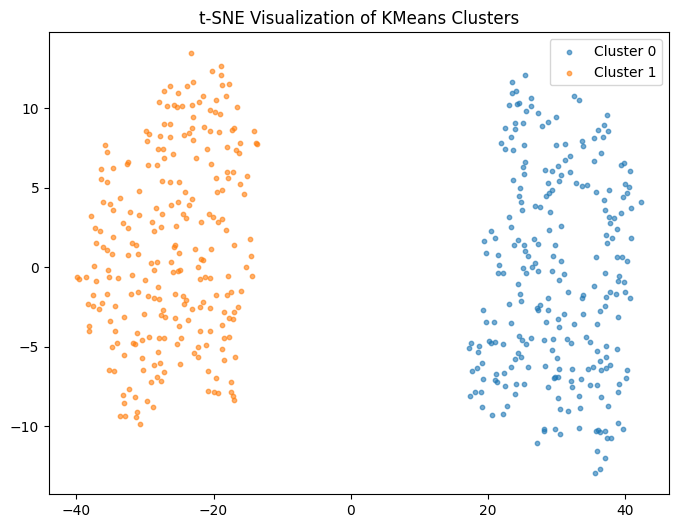

In [5]:
def kmeans_clustering(features, n_clusters=10):
    """Performs KMeans clustering on extracted features."""
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    predictions = kmeans.fit_predict(features)
    return kmeans, predictions

def visualize_tsne(features, predictions, n_clusters=10):
    """Performs t-SNE and visualizes clusters."""
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    reduced_features = tsne.fit_transform(features)

    plt.figure(figsize=(8, 6))
    for i in range(n_clusters):
        plt.scatter(
            reduced_features[predictions == i, 0], reduced_features[predictions == i, 1], 
            label=f'Cluster {i}', alpha=0.6, s=10,
        )
    
    plt.legend()
    plt.title("t-SNE Visualization of KMeans Clusters")
    plt.show()

def main(data, labels, n_clusters=10, device="cuda"):
    kmeans, predictions = kmeans_clustering(data, n_clusters)
    visualize_tsne(data, predictions, n_clusters)
    

main(X, y, n_clusters=2)

In [6]:
# create dataset
class ClusteredDataset(Dataset):
    def __init__(self, cluster_number=cluster_number, n_features=n_features, n_samples=n_samples, seed=42):
        np.random.seed(seed)

        X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=cluster_number, random_state=seed)
        labels = apply_functions(X)

        # Print shape to verify
        print("Feature matrix shape:", X.shape)
        print("Labels shape:", labels.shape)

        self.data = torch.tensor(X, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# Function to load the dataset
def load_dataset(batch_size=128, cluster_number=2,n_features=4,n_samples=500):
    dataset = ClusteredDataset(cluster_number=cluster_number, n_features=n_features, n_samples=n_samples)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True), dataset

In [7]:
# simple linear model
import torch.nn as nn
class SimpleNN(nn.Module):
    def __init__(self, input_dim, output_dim=45):
        super(SimpleNN, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)  # Directly define the layer

    def forward(self, x):
        return self.linear(x)  # No need for Sequential

In [8]:
def update_alpha(resp, u, alpha, max_iter=10, tol=1e-4):
    'updates alpha when maximizing the log likelihood with newton method'
    for _ in range(max_iter):
        f_alpha = -torch.sum(
                resp * (1 + (torch.log(u) - u) + torch.special.digamma(alpha / 2) - torch.log(alpha/ 2))
            )
        f_prime_alpha = (1 / alpha) - (0.5 * torch.special.polygamma(1, alpha / 2))  # Trigamma function
        alpha_new = alpha - f_alpha / f_prime_alpha  # Newton-Raphson update

        alpha_new = torch.clamp(alpha_new, min=0.01, max=10)

        if torch.abs(alpha_new - alpha) < tol:
            break

        alpha = alpha_new.detach()
    return alpha

In [9]:

def soft_assignments_mult(encoded_features, cluster_centers, sigma, mixing_coefficient, alpha=1, p=1):
    sigma_inv = 1.0 / sigma 
    #+1e-8 # (K,)
    diff = (encoded_features.T.unsqueeze(1) - cluster_centers.unsqueeze(0)) #(N,K,D)
    #print(diff.shape)
    norm_sigma = torch.sum((diff **2 * sigma_inv),2)  
    det = torch.sqrt(torch.prod(sigma, dim=1))
    #print('det', det.shape)
    assignments = 1.0 / (1.0 + (norm_sigma / alpha))
    assignments = mixing_coefficient * (assignments ** ((alpha + p) / 2))/det
    #print('Assignments shape', assignments.shape)
    return assignments / torch.sum(assignments, dim=1, keepdim=True)

def target_distribution(batch: torch.Tensor, exponent=exponent) -> torch.Tensor:
    weight = (batch**exponent) / torch.sum(batch, 0)
    return (weight.t() / torch.sum(weight, 1)).t()

def EM_t_mult(features, resp, cluster_centers, sigma, alpha, d=1):
    sigma_inv = 1.0 / sigma  # (K,D)
    diff = (features.T.unsqueeze(1) - cluster_centers.unsqueeze(0))
    norm_sigma = torch.sum((diff **2 * sigma_inv),2)  
    u = ((alpha + d)/(alpha +norm_sigma)).detach()  #ccalculate U shape(N,K)
    #print('u', u.shape)
    #print(resp.shape)
    
    ''' M step '''
    N=resp.shape[0]
    mixing_coefficient = (torch.sum(resp,0)/N).detach()
    print(mixing_coefficient.shape)

    numerator = torch.matmul(features,resp*u).T.detach()
    #print(numerator.shape)
    denominator = torch.sum(resp*u, dim=0, keepdim=True).T.detach()
    #print(denominator.shape)
    cluster_centers = numerator/denominator

    weighted_sq_diff = resp.unsqueeze(2)* u.unsqueeze(2) * (diff ** 2)  # (N, K, D)
    numerator = weighted_sq_diff.sum(dim=0) #(K,D)
    denominator = torch.sum(resp, dim=0, keepdim=True)  # (K,)
    #print('sigma de', denominator.shape)
    sigma = (numerator / denominator.T).detach() 
    sigma = torch.clamp(sigma, min=1e-6, max=1e6)
    #print('Tau', sigma.shape)

    #learn alpha
    #opt_alpha = update_alpha(resp, u, alpha, max_iter=10, tol=1e-4)

    return cluster_centers, sigma, mixing_coefficient, alpha

In [10]:
def EM_t_1D(features, resp, cluster_centers, taus, alpha, d=1):
    norm_squared = torch.sum(
    (features.T.unsqueeze(1) - cluster_centers.unsqueeze(0)) ** 2, dim=2
    )  
    u = (alpha + d)/(alpha +norm_squared*(taus**(-1)))  #ccalculate U shape(N,K)
    #print('u', u.shape)
    #print(resp.shape)
    ''' M step '''
    numerator = torch.matmul(features,resp*u).T.detach()
    #print(numerator.shape)
    denominator = torch.sum(resp*u, dim=0, keepdim=True).T.detach()
    #print(denominator.shape)
    cluster_centers = numerator/denominator

    weighted_sums = torch.sum(resp* u * norm_squared, dim=0) 
    #print('WS', weighted_sums.shape)
    taus = (weighted_sums / torch.sum(resp, dim=0, keepdim=True)).detach()
    #print('Tau', taus.shape)
    return cluster_centers, taus


def soft_assignments_1D(encoded_features, cluster_centers, tau, alpha=1, p=1):
    norm_squared = torch.sum(
        (encoded_features.T.unsqueeze(1) - cluster_centers.unsqueeze(0)) ** 2, 2
    )
    assignments = 1.0 / (1.0 + (norm_squared / (alpha * tau)))
    assignments = (assignments ** ((alpha + p) / 2))/(tau**1/2)
    #print('Assignments shape', assignments.shape)
    return assignments / torch.sum(assignments, dim=1, keepdim=True)

In [11]:
def trainer(model, dataloader, cluster_number=cluster_number, kmeans_init=10, 
            dec_starting_epoch=dec_starting_epoch,
            use_wandb = True,
            use_diag_cov=True,
            learn_alpha=True,
            log_likelihood_alpha=False,
            exponent=exponent, lr=0.008, epochs=100, device=device, alpha = 1.0):
    '''
    use_diag_conv: Bool that indicates wether to use a diagonal covariance matrix or just one value for each cluster
    log_likelihood_alpha: Says wether to optimize alpha with the help of its log likelihood
    '''
    if learn_alpha:
        alpha = torch.nn.Parameter(torch.tensor(1.0, device=device, requires_grad=True))
        optimizer = torch.optim.Adam(list(model.parameters()) + [alpha], lr=lr)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    kldiv_criterion = KLDivLoss(
        size_average=False
    )  # losses are summed for each minibatch
    criterion = nn.MSELoss()

    if use_wandb:
        wandb.init(
            project='Toy example',
            entity='ninasophie-nellen-g-ttingen-university',
            name=f'epsilon 5, MSE 0, diag cov, alpha {alpha}, dim p',
            config={
                "learning_rate": lr,
                "cur_epochs": epochs,
            },
        )
        wandb.run.log_code(".")
        # metrics represent any value I want to track, if they're hidden, they're not displayed on default cisualisation
        wandb.define_metric(name="Epoch", hidden=True)
        wandb.define_metric(name="Batch", hidden=True)

    model.to(device)
    model.train()
    for epoch in range(epochs):

        epoch_loss = 0
        epoch_kldiv_loss = 0
        epoch_loss_main = 0
        '''
        if epoch >= 50:
            lr = 0.0005
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        '''
        if epoch == dec_starting_epoch:
            cluster_centers_list = []
            features = model.linear.weight.data.detach().cpu().numpy()
            #print(features.shape)
            kmeans = KMeans(
                n_clusters=cluster_number, n_init=kmeans_init, random_state=seed
            )
            with torch.no_grad():
                predicted = kmeans.fit_predict(features)

            cluster_centers = torch.tensor(
                kmeans.cluster_centers_, dtype=torch.float, device=device, requires_grad=True,
            )
            mixing_coefficient = torch.ones(cluster_number, device=device) / cluster_number 
            if use_diag_cov:
                p = features.shape[1]
                sigma = torch.zeros((cluster_number,p), device=device)
                for k in range(cluster_number):
                    cluster_points = torch.from_numpy(features[predicted == k]).to(device) 
                    if len(cluster_points) > 0:
                        sigma[k] = torch.var(cluster_points, dim=0, unbiased=True) +1e-6

            else: 
                sigma = torch.zeros(cluster_number, device=device)
                for k in range(cluster_number):
                    cluster_points = torch.from_numpy(features[predicted == k]).to(device)  
                    if len(cluster_points) > 0:
                        sigma[k] = torch.mean(torch.sum((cluster_points - cluster_centers[k])**2,1))
                sigma = sigma.unsqueeze(0)
                p=1
            if learn_alpha:
                alpha.data = torch.tensor(1.0, dtype=torch.float, device=device)

            print('Sigma beginning', sigma)
            with torch.no_grad():
                cluster_centers_list.append(cluster_centers.cpu().detach().numpy())
            plt.scatter(features[:,0], features[:,1])
            plt.scatter(cluster_centers_list[0][:,0], cluster_centers_list[0][:,1])
            plt.title('Visualisation of the features and cluster centers at initialisation')
            plt.show()
            fig, axes = plt.subplots(4, 4, figsize=(12, 12))  # 4x4 grid of subplots

        for i, (inputs, labels) in enumerate(dataloader): 
            #if epoch < dec_starting_epoch:
            inputs = inputs.to(device)     
            labels = labels.to(device) 
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward() 
            if epoch >= dec_starting_epoch:
                loss = torch.zeros(1, device=device)
            epoch_loss += loss.detach()
            epoch_loss_main += loss.detach() 
                
            if epoch >= dec_starting_epoch:
                features = model.linear.weight.T
                if use_diag_cov:
                    q = soft_assignments_mult(features, cluster_centers, sigma, mixing_coefficient, alpha,p)
                    #encoded_features, cluster_centers, sigma, mixing_coefficient, alpha=1, p=1
                else:
                    q = soft_assignments_1D(features, cluster_centers, sigma, alpha,p)
                target = target_distribution(q, exponent)

                '''
                if epoch < dec_starting_epoch + 1:
                    print('Q', q)
                    print('Targets', target)
                '''
                kldiv_loss = 10 * kldiv_criterion(q.log(), target)
                kldiv_loss.backward()

                epoch_kldiv_loss += kldiv_loss.detach()
                #print('KL loss', kldiv_loss)
                epoch_loss += kldiv_loss.detach()
                if use_diag_cov:
                    cluster_centers, sigma, mixing_coefficient, opt_alpha = EM_t_mult(features, q, cluster_centers, sigma, alpha, p)
                else:
                    cluster_centers, sigma = EM_t_1D(features, q, cluster_centers, sigma, alpha, p)

                if log_likelihood_alpha:
                    alpha = opt_alpha
                print(q)
                print(sigma)
                with torch.no_grad():
                    cluster_centers_np = cluster_centers.cpu().detach().numpy()
                    cluster_centers_list.append(cluster_centers_np)
                    features_np = features.detach().cpu().numpy()
                    if epoch < dec_starting_epoch+1:
                        #print('KL loss:', kldiv_loss)
                        ax = axes[i // 4, i % 4]  # Select subplot position
                        ax.scatter(features_np[:, 0], features_np[:, 1], label="Features", alpha=0.6)
                        ax.scatter(cluster_centers_np[:, 0], cluster_centers_np[:, 1], color='red', marker='x', label="Cluster Centers")
                        ax.set_title(f'Batch {i}')  
                        ''''
                        plt.scatter(features_np[:,0], features_np[:,1])
                        plt.scatter(cluster_centers_np[:,0], cluster_centers_np[:,1])
                        plt.title(f'Visualisation of the features and cluster centers at batch {i}')
                        plt.show() 
                        '''
            optimizer.step()  
            optimizer.zero_grad()   

        if use_wandb:
            wandb_dict = {
                "Epoch Train loss": epoch_loss,
                "Epoch Train loss main": epoch_loss_main,
                "Epoch Train loss Kullback-Leibler-divergence": epoch_kldiv_loss,
            }
            wandb.log(wandb_dict)

    plt.tight_layout()  # Adjust layout to prevent overlapping
    plt.show()
    print(cluster_centers)
    print("Training Complete!")
    model.eval()
    features = model.linear.weight.data.detach()
    if use_diag_cov:
        q = soft_assignments_mult(features.T, cluster_centers, sigma, mixing_coefficient, alpha,p)
    else:
        q = soft_assignments_1D(features.T, cluster_centers, sigma, alpha,p)
    features = (features).cpu().numpy()
    predictions = (q).max(1)[1].cpu().numpy()
    cluster_centers_np = np.array(cluster_centers_list)

    #print('features: ', features.shape)
    #print('predictions: ', predictions.shape)
    print('cluster centers ', cluster_centers_np.shape)
    print('TAu', sigma)
    print('Alpha ', alpha)
    print('resp', mixing_coefficient)
    return features, predictions, cluster_centers_np

Feature matrix shape: (500, 2)
Labels shape: (500, 45)


/user/ninasophie.nellen/anaconda3/envs/my_env/lib/python3.12/site-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))


Sigma beginning tensor([[0.0068, 0.0075],
        [0.0052, 0.0059]], device='cuda:5')


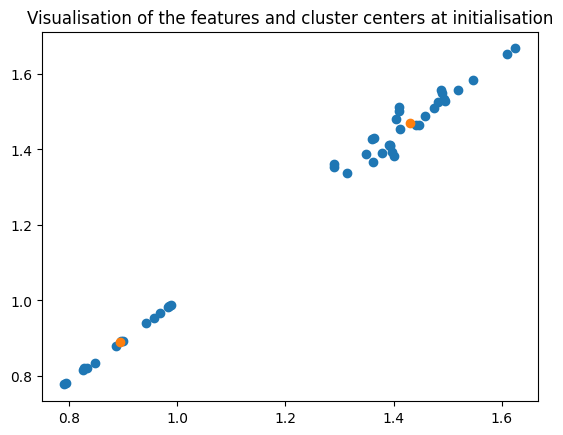

torch.Size([2])
tensor([[1.9166e-03, 9.9808e-01],
        [2.6743e-03, 9.9733e-01],
        [6.4785e-03, 9.9352e-01],
        [3.1197e-03, 9.9688e-01],
        [9.6377e-04, 9.9904e-01],
        [7.7372e-03, 9.9226e-01],
        [1.4821e-02, 9.8518e-01],
        [3.0739e-03, 9.9693e-01],
        [6.1729e-03, 9.9383e-01],
        [9.2989e-04, 9.9907e-01],
        [9.4653e-04, 9.9905e-01],
        [1.3266e-02, 9.8673e-01],
        [1.2203e-02, 9.8780e-01],
        [5.1118e-03, 9.9489e-01],
        [2.8549e-03, 9.9715e-01],
        [9.7342e-01, 2.6583e-02],
        [9.9715e-01, 2.8547e-03],
        [9.6968e-01, 3.0317e-02],
        [9.7262e-01, 2.7376e-02],
        [9.8267e-01, 1.7335e-02],
        [9.9800e-01, 1.9995e-03],
        [9.9688e-01, 3.1157e-03],
        [9.9722e-01, 2.7839e-03],
        [9.9865e-01, 1.3487e-03],
        [9.9370e-01, 6.2996e-03],
        [9.9501e-01, 4.9936e-03],
        [9.9607e-01, 3.9291e-03],
        [9.9882e-01, 1.1823e-03],
        [9.9608e-01, 3.9203e-03]

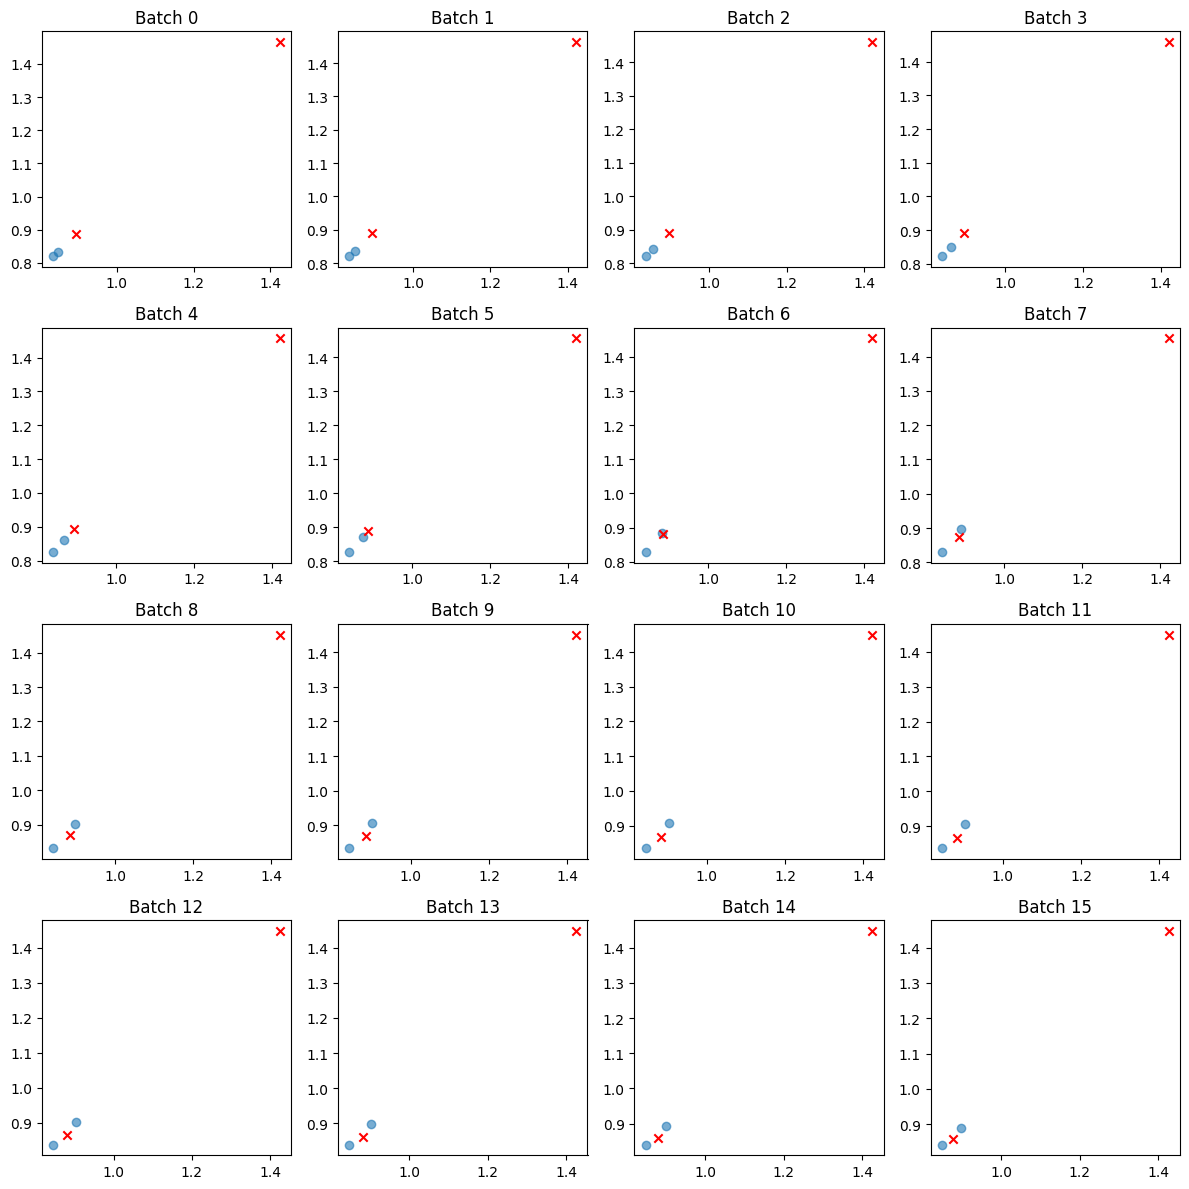

tensor([[1.4109, 1.4376],
        [0.9508, 0.9473]], device='cuda:5')
Training Complete!
cluster centers  (1121, 2, 2)
TAu tensor([[1.0000e-06, 2.5082e-04],
        [6.4140e-04, 7.7217e-04]], device='cuda:5')
Alpha  Parameter containing:
tensor(1.3973, device='cuda:5', requires_grad=True)
resp tensor([0.6667, 0.3333], device='cuda:5')


In [20]:
dataloader, dataset = load_dataset(batch_size=32, n_features=2)
model = SimpleNN(input_dim=2, output_dim=45)
features, predictions, cluster_centers_list = trainer(model, dataloader, dec_starting_epoch=30, 
                                                       cluster_number=2,
                                                       exponent=2, epochs=100, use_wandb=False, 
                                                       use_diag_cov=True, 
                                                       log_likelihood_alpha=False,
                                                       learn_alpha=True, alpha=1.9)

In [21]:
cluster_centers = cluster_centers_list[-1]
print(features)

[[0.8791854  0.8687095 ]
 [0.87147427 0.86021006]
 [0.84962213 0.8365857 ]
 [0.9463411  0.9423239 ]
 [0.96426845 0.96329015]
 [0.9643568  0.962151  ]
 [0.9696327  0.96801627]
 [0.87859726 0.86884874]
 [0.86485744 0.85339665]
 [0.9142015  0.9065957 ]
 [0.9271579  0.9224471 ]
 [0.9682514  0.966361  ]
 [0.9684845  0.9666563 ]
 [0.9556709  0.9523187 ]
 [0.868959   0.85833305]
 [1.4102294  1.4213892 ]
 [1.4118594  1.4732662 ]
 [1.4101119  1.412254  ]
 [1.4100707  1.417491  ]
 [1.4119549  1.4573746 ]
 [1.4118575  1.4718732 ]
 [1.41117    1.4259807 ]
 [1.4111999  1.4447469 ]
 [1.4112846  1.4489864 ]
 [1.4122753  1.4638273 ]
 [1.4109489  1.4234487 ]
 [1.4119675  1.4642563 ]
 [1.4107283  1.4283385 ]
 [1.4115014  1.4398466 ]
 [1.4105885  1.428358  ]
 [1.4102392  1.4256508 ]
 [1.4104891  1.436747  ]
 [1.4120231  1.4579767 ]
 [1.4120408  1.4566679 ]
 [1.4108632  1.4342031 ]
 [1.4118242  1.4839295 ]
 [1.4107406  1.4316477 ]
 [1.4122243  1.4595228 ]
 [1.4103895  1.428304  ]
 [1.4119695  1.4380012 ]


In [22]:
print(predictions)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0]


In [23]:
print(cluster_centers)

[[1.4109029 1.4376149]
 [0.9507946 0.9473483]]


Text(0.5, 1.0, 'Visualisation of the features and cluster centers')

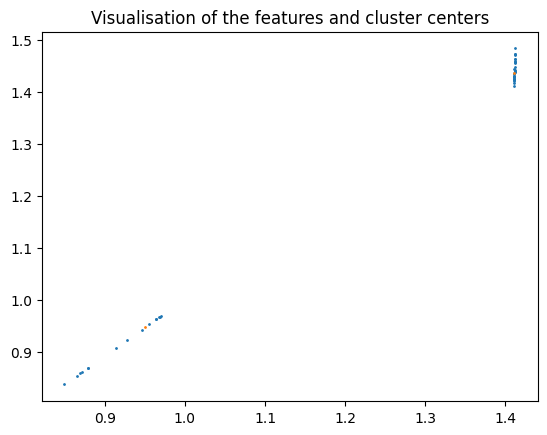

In [24]:
plt.scatter(features[:,0], features[:,1], s = 1)
plt.scatter(cluster_centers[:,0], cluster_centers[:,1], s = 1)
plt.title('Visualisation of the features and cluster centers')

In [17]:
from sklearn.manifold import TSNE

def visualize_clusters(features, predictions, cluster_centers):

    n = features.shape[0]
    perplexity = 10
    lr = n/12
    print(features.shape)
    print(cluster_centers.shape)

    plt.figure(figsize=(8,10), dpi=80)

    colors = plt.cm.get_cmap("tab10", cluster_number)  # Define colors for clusters
    color_map = {label: colors(i) for i, label in enumerate(range(cluster_number))}

    combined_data = np.vstack([features, cluster_centers])  # Stack features with centers

    # Apply t-SNE to combined data
    tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, random_state=42)
    embedded_data = tsne.fit_transform(combined_data)  # Run on combined data

    embedded_points = embedded_data[:n]  # First part corresponds to data points
    embedded_centers = embedded_data[n:]  # Last part corresponds to cluster centers

    for value in range(cluster_number):
        cluster_mask = predictions == value
        print(f"Cluster {value}: Mask shape = {cluster_mask.shape}, Points = {cluster_mask.sum()}")
        
        plt.scatter(
            embedded_points[cluster_mask, 0],
            embedded_points[cluster_mask, 1],
            c=[color_map[value]],
            label=f'Cluster {value}',
            alpha=0.7,
            s=1,
        )
        plt.scatter(
            embedded_centers[value][0],
            embedded_centers[value][1],
            c=[color_map[value]],  # Mapped color
            marker='X',
            s=100,
            edgecolor='black',
            label='Cluster Center'
        )

    plt.title(f'clustered data')

    # Adjust layout for better spacing
    plt.tight_layout()

    # Add legend automatically from the scatter plot
    plt.legend(title='Clusters', loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
    plt.show()

(45, 2)
(2, 2)


/tmp/ipykernel_3894134/1642927351.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", cluster_number)  # Define colors for clusters


Cluster 0: Mask shape = (45,), Points = 30
Cluster 1: Mask shape = (45,), Points = 15


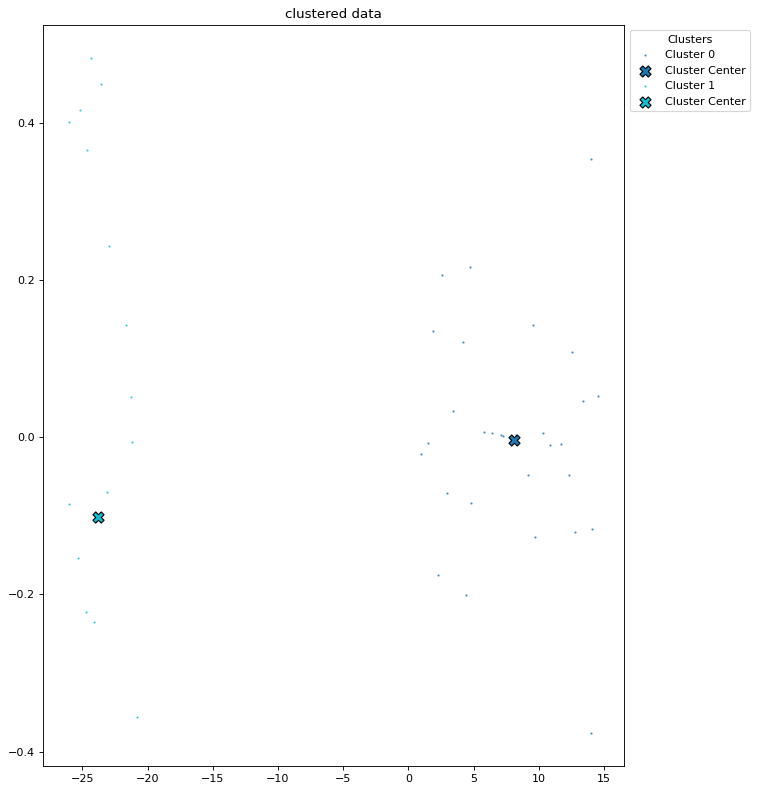

In [18]:
visualize_clusters(features, predictions, cluster_centers_list[-1])

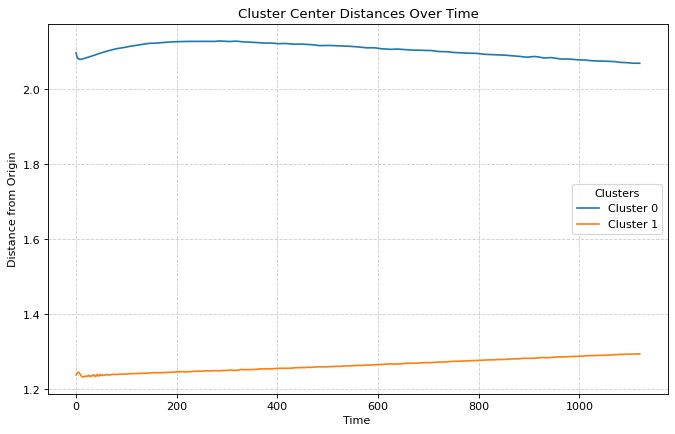

In [19]:
time = cluster_centers_list.shape[0]
end_time = time
cluster_centers_distances=np.zeros((time, cluster_number)) 

for batch in range(time):
    cluster_centers_distances[batch][:] = np.linalg.norm(cluster_centers_list[batch],axis=1)

# Plot the distances of the cluster centers over time
plt.figure(figsize=(10, 6), dpi=80)


for cluster_idx in range(cluster_number):
    #if cluster_idx in unique_values:
    plt.plot(range(end_time), cluster_centers_distances[:end_time, cluster_idx], label=f'Cluster {cluster_idx}')

#plt.plot(range(end_time),kldiv_loss_batches[: end_time], label = 'kldiv_loss')
plt.xlabel('Time ')
plt.ylabel('Distance from Origin')
plt.title('Cluster Center Distances Over Time')
plt.legend(title='Clusters', loc='center right', frameon=True)
plt.grid(True, linestyle='--',alpha=0.6)
plt.show()